In [4]:
import numpy as np
import matplotlib.pyplot as plt

from create_grid import (
    apply_SVD_to_A,
    create_A_matrix,
    create_DT2_grid,
    create_M0_true,
    create_W_true,
    create_gaussian_compartments,
    create_signal,
)
from optimiser_alpha_gamma import *
from plotting import *


In [2]:
Dmin, T2min, Dmax, T2max, nD, nT2 = 0.2, 20.0, 2.0, 150.0, 20, 20
Bmin, Bmax, nB, TEmin, TEmax, nTE = 0.0, 4.0, 8, 20.0, 180.0, 8
R, K = 10, 3
alpha_true = 1.5
n_voxels = 80
sigma_true = 0.002
eps = 1e-10
rng = np.random.default_rng(1)

D_means = [0.4, 0.9, 1.6]
D_stds = [0.10, 0.12, 0.16]
T2_means = [90, 55, 120]
T2_stds = [15, 10, 18]

rng = np.random.default_rng(1)
D_grid, T2_grid = create_DT2_grid(Dmin, Dmax, nD, T2min, T2max, nT2)
D_vals = np.linspace(Dmin, Dmax, nD)
T2_vals = np.linspace(T2min, T2max, nT2)
A = create_A_matrix(D_grid, T2_grid, Bmin, Bmax, nB, TEmin, TEmax, nTE)
U, s, V_mat = apply_SVD_to_A(A, R)

C_true = create_gaussian_compartments(
    D_grid, T2_grid, D_means, D_stds, T2_means, T2_stds,
)
W_true = create_W_true(K, n_voxels, alpha_true, rng)
M0_true = create_M0_true(0.7, 1.3, n_voxels, rng)
Y = create_signal(A, C_true, W_true, M0_true, sigma_true, rng)
C_small_true = np.diag(s) @ V_mat.T @ C_true
sigma2_true = sigma_true ** 2
lam_true = define_initial_lambda(C_small_true, R, K)
W0, M0_init = define_initial_W_and_m(K, n_voxels, rng)

## Plotting weight convergence

This small diagnostic records the voxel weights `W` at every optimisation iteration and plots their trajectories for a few representative voxels.

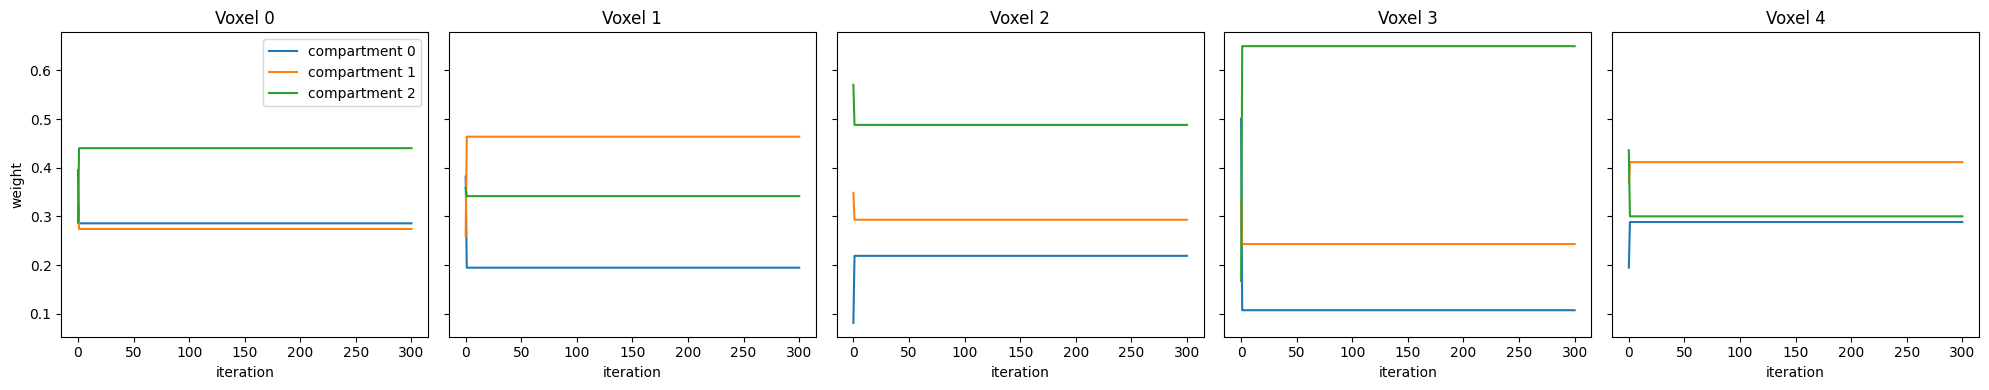

In [3]:
def run_optimisation_tracked(
    Y, U, C_small, M0, K, R, eps, n_iter, sigma2, alpha, lam, W,
    bound_eps=1e-2,
):
    W_history = [W.copy()]

    for _ in range(n_iter):
        UC = U @ C_small
        W = update_W(Y, UC, sigma2, alpha, W, M0, bound_eps)
        alpha = update_alpha(W)
        W_history.append(W.copy())

    return W, alpha, np.asarray(W_history)

C_small_true_init = np.diag(s) @ V_mat.T @ C_true
W_est, alpha_est, W_history = run_optimisation_tracked(
    Y, U, C_small_true_init, M0_true, K, R, eps,
    n_iter=300,
    sigma2=sigma2_true,
    alpha=alpha_true,
    lam=lam_true,
    W=W0,
)

voxels_to_plot = [0, 1, 2, 3, 4]
fig, axes = plt.subplots(
    1, len(voxels_to_plot), figsize=(4 * len(voxels_to_plot), 4), sharey=True,
)
for ax, voxel_index in zip(axes, voxels_to_plot):
    for compartment_index in range(K):
        ax.plot(
            W_history[:, compartment_index, voxel_index],
            label=f"compartment {compartment_index}",
        )
    ax.set_title(f"Voxel {voxel_index}")
    ax.set_xlabel("iteration")
axes[0].set_ylabel("weight")
axes[0].legend()
plt.tight_layout()
plt.show()

With C fixed at the truth, W converges within about 10 iterations and then stays flat. This checks the W update on its own, not the full pipeline